# **Audio Classification with Deep Learning**

---



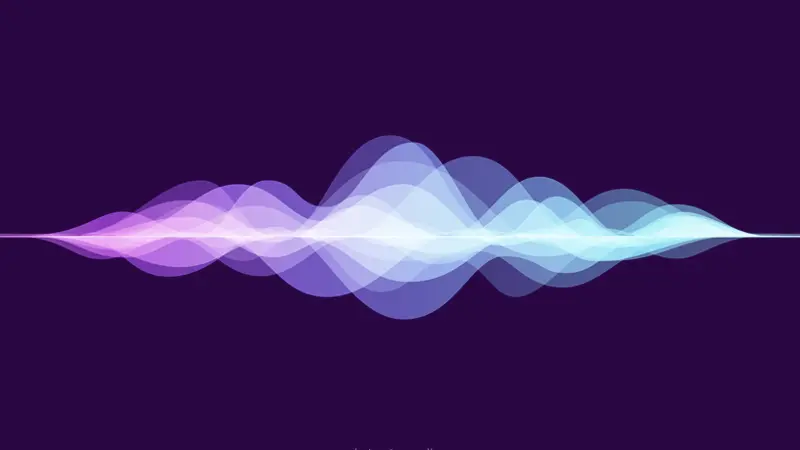

## Business Understanding
### Background

Urban areas generate many different sounds every day, such as car horns, sirens, dog barking, drilling, street music, and engine noises. Monitoring and identifying these sounds manually is difficult, time-consuming, and expensive.

With the growth of smart cities and intelligent monitoring systems, there is a need for automated solutions that can accurately recognize and classify urban sounds in real time.

## Business Problem

Organizations responsible for public safety, environmental monitoring, and smart city management often struggle to monitor urban sound events continuously.

Important sounds such as emergency sirens, gunshots, or construction noise may require immediate attention, but manual monitoring is not practical.

The challenge is to develop an intelligent system that can automatically identify different urban sound categories from audio recordings.

## Problem Statement

Can we build a deep learning model that accurately classifies urban audio recordings into one of the following ten sound categories?

Air Conditioner
Car Horn
Children Playing
Dog Bark
Drilling
Engine Idling
Gun Shot
Jackhammer
Siren
Street Music

## Objectives
### Main Objective

Develop a Convolutional Neural Network (CNN) model capable of classifying urban sounds based on audio recordings.

Specific Objectives
Load and explore the UrbanSound8K dataset.
Convert raw audio signals into Mel-Spectrogram representations.
Perform feature extraction using Librosa.
Train a CNN model on spectrogram images.
Evaluate model performance using classification metrics.
Build a system capable of predicting sound categories from unseen audio files.

## Stakeholders

The project may benefit:

Smart City Authorities
Environmental Monitoring Agencies
Public Safety Departments
Traffic Management Authorities
Security Organizations
Researchers in Audio Analytics

## Business Impact

A successful solution can:

✅ Improve public safety

✅ Detect emergency situations faster

✅ Reduce manual monitoring costs

✅ Support smart city initiatives

✅ Enable automated urban noise monitoring

## Success Metrics

The project will be considered successful if the model achieves:

High Classification Accuracy
High Precision
High Recall
High F1 Score
Strong performance across all 10 sound classes

## Analytical Questions
Which sound classes have the highest number of recordings?  
Is the dataset balanced across classes?  
Does salience affect classification performance?  
Which classes are most frequently confused by the model?  
What overall accuracy can be achieved using CNNs?

## Machine Learning Approach
### Type of Problem

Multi-Class Classification

Input

Audio recordings (.wav)

Feature Engineering

Audio → Mel-Spectrogram

Model

Convolutional Neural Network (CNN)

Output

Predicted Sound Class

Example:

Input: audio.wav

Prediction: Siren
Confidence: 96%

## Data Preparation

Before building the machine learning model, the dataset must be prepared and transformed into a format suitable for analysis and modeling.

## Data Understanding
## Dataset Overview

Dataset Name: UrbanSound8K

Dataset Size:

8,732 audio files
WAV format
10 sound categories

Target Variable:

class

Examples:

siren  
dog_bark  
car_horn  
drilling  
gun_shot

Important Features:

fold  
classID  
class  
salience  
start  
end

## Feature Description
### slice_file_name

Unique audio filename.

Example:

100032-3-0-0.wav
### fsID

Unique Freesound recording identifier.

Purpose:

Identifies the original source recording.
### start

Starting timestamp of the audio slice within the original recording.

### end

Ending timestamp of the audio slice.

#### salience

Indicates the prominence of the sound.

Value	Meaning
1	Foreground Sound
2	Background Sound

### classID

Numeric label assigned to each sound category.

Class ID	Sound Category
0	air_conditioner
1	car_horn
2	children_playing
3	dog_bark
4	drilling
5	engine_idling
6	gun_shot
7	jackhammer
8	siren
9	street_music
### class (Target Variable)

Represents the sound category the model will predict.

Examples:

dog_bark
siren
drilling
gun_shot
### Target Variable Analysis

This project is a:

Multi-Class Classification Problem

The model's objective is to predict the correct sound category from the audio recording.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing
import librosa
import librosa.display

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization



In [5]:
df = pd.read_csv('data/UrbanSound8K.csv')

df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
import sys
!{sys.executable} -m pip install --user librosa

  Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
  Using cached scikit_learn-1.3.2-cp38-cp38-win_amd64.whl (9.3 MB)
  Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
  Using cached numba-0.58.1-cp38-cp38-win_amd64.whl (2.6 MB)
  Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
  Using cached llvmlite-0.41.1-cp38-cp38-win_amd64.whl (28.1 MB)
  Using cached platformdirs-4.3.6-py3-none-any.whl (18 kB)


In [3]:
import librosa
import librosa.display
print(librosa.__version__)

0.11.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


In [ ]:
#Check Missing Values
df.isnull().sum()

slice_file_name    0
fsID               0
start              0
end                0
salience           0
fold               0
classID            0
class              0
dtype: int64

In [9]:
# checking for duplicates
df.duplicated().sum()

0

In [10]:
#Summary Statistics
df.describe()

,fsID,start,end,salience,fold,classID
count,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000
mean,116033.493816,38.645409,42.253312,1.347000,5.385937,4.592877
std,57991.017218,74.292126,74.369669,0.476043,2.846820,2.894544
min,344.000000,0.000000,0.105962,1.000000,1.000000,0.000000
25%,69942.250000,3.000000,6.839398,1.000000,3.000000,2.000000
50%,118279.000000,10.376492,14.000000,1.000000,5.000000,4.000000
75%,166942.000000,35.131372,38.866979,2.000000,8.000000,7.000000
max,209992.000000,600.125356,604.125356,2.000000,10.000000,9.000000


## EDA (Exploratory Data Analysis)

### 1. Class Distribution

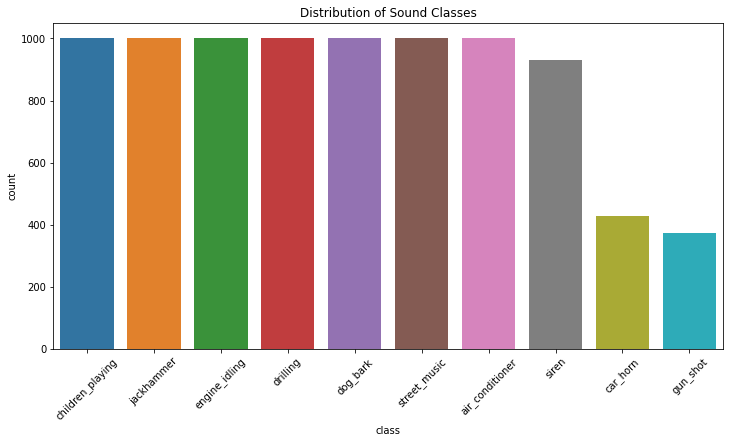

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='class',
    order=df['class'].value_counts().index
)

plt.title('Distribution of Sound Classes')
plt.xticks(rotation=45)
plt.show()

### 2. Salience Distribution


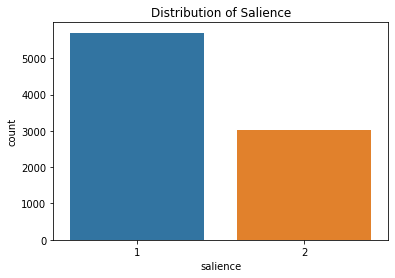

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='salience'
)

plt.title('Distribution of Salience')
plt.show()

Shows the number of:

Foreground sounds (1)
Background sounds (2)

### 3. Class vs Salience

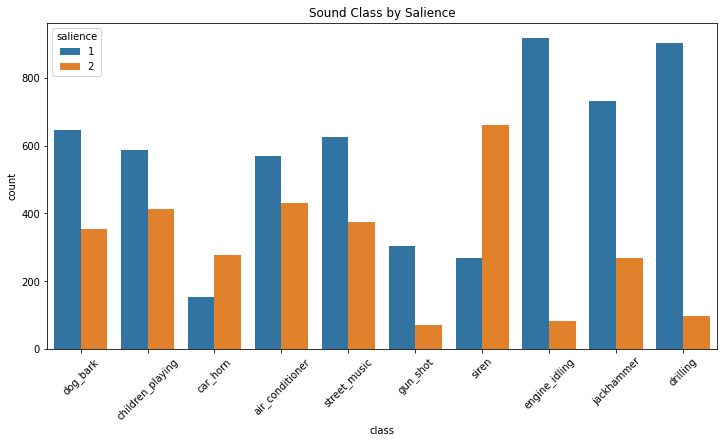

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='class',
    hue='salience'
)

plt.xticks(rotation=45)
plt.title('Sound Class by Salience')
plt.show()

### 4. Fold Distribution

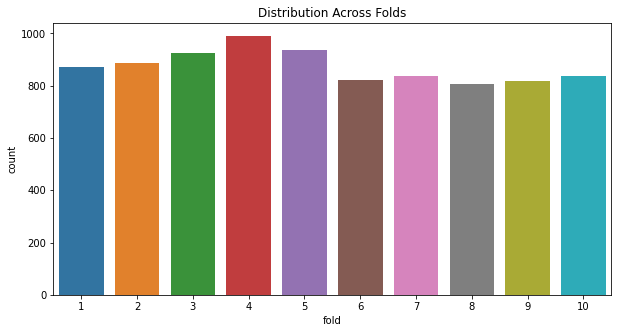

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='fold'
)

plt.title('Distribution Across Folds')
plt.show()

### 5. Sound Classes Across Folds

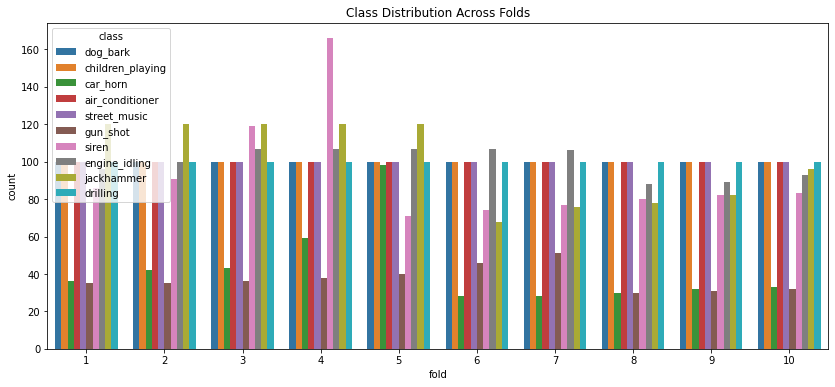

In [16]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='fold',
    hue='class'
)

plt.title('Class Distribution Across Folds')
plt.show()

### 5. Correlation Heatmap

In [19]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.head()

,fsID,start,end,salience,fold,classID
0,100032,0.0,0.317551,1,5,3
1,100263,58.5,62.500000,1,5,2
2,100263,60.5,64.500000,1,5,2
3,100263,63.0,67.000000,1,5,2
4,100263,68.5,72.500000,1,5,2


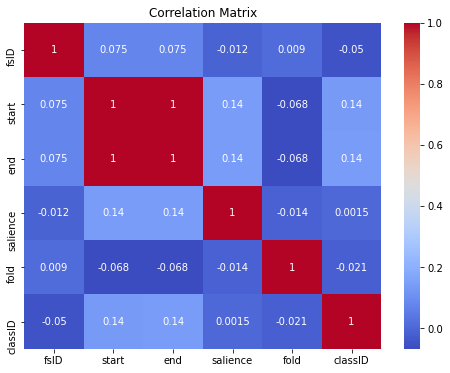

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()